In [9]:
import os
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated  
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from IPython.display import Image
from langgraph.checkpoint.memory import MemorySaver


# Buiding an Agent

In [2]:
# Ensure you have your TAVILY_API_KEY and OPENAI_API_KEY set
tool = TavilySearchResults(max_results=4)
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


/tmp/ipykernel_58866/2850482353.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=4)


In [3]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [10]:
memory = MemorySaver()

In [11]:
class Agent: 
    def __init__(self, model, tools, checkpointer, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        
        graph.add_node("llm", self.call_openai)
        graph.add_node("action", self.take_action) 
        
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm") 
        self.graph = graph.compile(checkpointer=checkpointer)
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_openai(self, state: AgentState):
        messages = state["messages"]
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages) 
        return {'messages': [message]}
    
    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:      # check for bad tool name from LLM
                print("\n ....bad tool name....")
                result = "bad tool name, retry"  # instruct LLM to retry if bad
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [12]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""

model = ChatOpenAI(
    model="google/gemini-2.5-flash-lite",
    base_url="https://openrouter.ai/api/v1", 
    openai_api_key=os.getenv("OPENROUTER_API_KEY"))  
abot = Agent(model, [tool], system=prompt, checkpointer=memory)

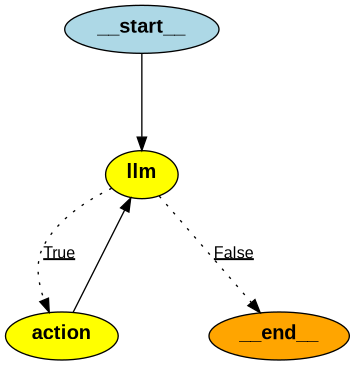

In [13]:
Image(abot.graph.get_graph().draw_png())

In [14]:
messages = [HumanMessage(content="What is the weather in sf?")]
thread = {"configurable": {"thread_id":"1"}}
result = abot.graph.invoke({"messages": messages}, thread)

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in sf'}, 'id': 'tool_tavily_search_results_json_zSof0jmbinKnIo2wR4Jf', 'type': 'tool_call'}
Back to the model!


In [15]:
result

{'messages': [HumanMessage(content='What is the weather in sf?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 13, 'prompt_tokens': 123, 'total_tokens': 136, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 1.75e-05, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 1.75e-05, 'upstream_inference_prompt_cost': 1.23e-05, 'upstream_inference_completions_cost': 5.2e-06}}, 'model_provider': 'openai', 'model_name': 'google/gemini-2.5-flash-lite', 'system_fingerprint': None, 'id': 'gen-1769626522-v9tY1xYIN2DFcVqq3SAI', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c05f5-d3e9-7a22-a1b3-84732617ddf7-0', tool_calls=[{'n

In [16]:
result['messages'][-1].content

'The weather in San Francisco in January 2026 is predicted to be:\n* Mostly Cloudy, with a temperature of 46.9°F.\n* There\'s a chance of showers, particularly in the north, with averages around 58°F and precipitation of 3".\n* The extended forecast suggests a mix of conditions, including sunny and cool days, as well as periods of rain.'

# Persistence

In [ ]:
messages = [HumanMessage(content="How about in San Antonio?")]
thread = {"configurable": {"thread_id":"1"}}
result = abot.graph.invoke({"messages": messages}, thread)
result['messages'][-1].content

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in San Antonio Texas January 2026'}, 'id': 'tool_tavily_search_results_json_GegOlVx1QCjbO8PQoRLs', 'type': 'tool_call'}
Back to the model!


"The weather in San Antonio in January 2026 is predicted to be:\n* Mostly sunny with temperatures ranging from 8°C to 17°C (46°F to 63°F).\n* There will be a few rainy days, but generally, it's expected to be dry with around 29 dry days.\n* Snowfall is rare and not expected in January 2026.\n* The forecast indicates a mix of conditions, with some periods of showers interspersed with sunny and mild weather."

# Streaming

In [ ]:
query = "Who won the super bowl in 2024? In what state is the winning team headquarters located? \
What is the GDP of that state? Answer each question." 
messages = [HumanMessage(content=query)]
thread = {"configurable": {"thread_id":"2"}}

model = ChatOpenAI(
    model="google/gemini-2.5-flash-lite",
    base_url="https://openrouter.ai/api/v1", 
    openai_api_key=os.getenv("OPENROUTER_API_KEY")) 

abot = Agent(model, [tool], system=prompt, checkpointer=memory)
# result = abot.graph.invoke({"messages": messages}, thread)

####--- streaming

for event in abot.graph.stream({"messages": messages}, thread):
    for v in event.values():
        print(v)

{'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 6485, 'total_tokens': 6532, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 0, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 0.0006673, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0.0006673, 'upstream_inference_prompt_cost': 0.0006485, 'upstream_inference_completions_cost': 1.88e-05}}, 'model_provider': 'openai', 'model_name': 'google/gemini-2.5-flash-lite', 'system_fingerprint': None, 'id': 'gen-1769626868-91mnXaoStGQ9PdeQ0wLl', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c05fb-1907-7423-b958-1c58c9d53231-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'who won super bowl 2024'}, 'id': 'too